# ch09 · 马尔可夫链

## Why this chapter
工程中很多问题本质上是"下一步去哪"的链上随机游走: PageRank 给网页排名、MCMC 给贝叶斯后验、强化学习的状态转移. 这一章把"过去与未来在现在条件下独立"那条 Markov 性质及其推论摊开.

## 学完后能解决
- 推细致平衡 (detailed balance) 给平稳分布
- 用 numpy 写 PageRank 数值实现
- 视觉化转移图谱与平稳收敛过程
- 解释 mixing time 与 spectral gap 关系
- 区分 irreducible / aperiodic / ergodic 三个条件


## 2. 直觉引入: 醉汉在 4 个酒馆的转移图

醉汉在 4 个酒馆之间随机走; 给定当前位置, 下一步要去哪只依赖当前位置, 不依赖历史 → Markov 性质. 给转移矩阵 P, 多步后稳定分布为 π 满足 πP = π.


转移矩阵 P:
[[0.2 0.5 0.2 0.1]
 [0.3 0.1 0.4 0.2]
 [0.1 0.3 0.4 0.2]
 [0.  0.2 0.3 0.5]]
row sums: [1. 1. 1. 1.]


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38142 (\N{CJK UNIFIED IDEOGRAPH-94FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

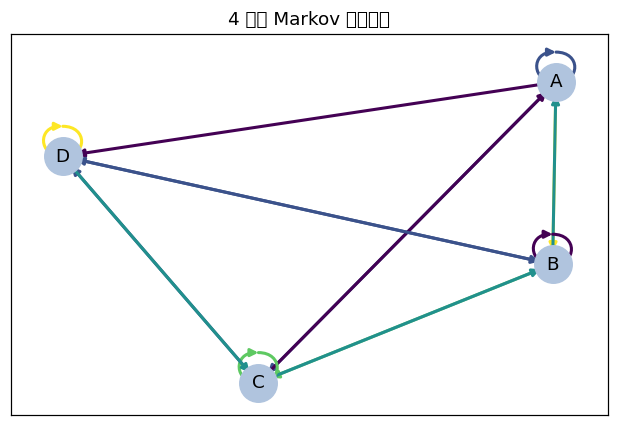

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 4 状态转移矩阵
P = np.array([
    [0.2, 0.5, 0.2, 0.1],  # 从 0
    [0.3, 0.1, 0.4, 0.2],  # 从 1
    [0.1, 0.3, 0.4, 0.2],  # 从 2
    [0.0, 0.2, 0.3, 0.5],  # 从 3
])
print("转移矩阵 P:")
print(P)
print("row sums:", P.sum(axis=1))

# 简单可视化: 节点 + 加权边
G = nx.DiGraph()
labels = {0: "A", 1: "B", 2: "C", 3: "D"}
for i in range(4):
    G.add_node(i, label=labels[i])
for i in range(4):
    for j in range(4):
        if P[i, j] > 0.001:
            G.add_edge(i, j, weight=P[i, j])
pos = nx.spring_layout(G, seed=42)
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=110)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="lightsteelblue", node_size=600)
nx.draw_networkx_labels(G, pos, ax=ax, labels=labels)
edges = G.edges(data=True)
weights = [d["weight"] for _, _, d in edges]
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=weights, edge_cmap=plt.cm.viridis,
                       width=2, arrows=True, arrowstyle="-|>")
ax.set_title("4 状态 Markov 链转移图")
plt.show()


## 3. 公式

### Markov 性质
$P(X_{n+1} = j \mid X_n, X_{n-1}, ...) = P(X_{n+1} = j \mid X_n)$

### 转移矩阵 P
Stochastic (行和为 1): $P_{ij} = P(X_{n+1}=j \mid X_n=i)$

n 步转移: $P^{(n)} = P^n$

### 平稳分布
$\pi P = \pi$, $\sum \pi_i = 1$

### Detailed balance (细致平衡)
$\pi_i P_{ij} = \pi_j P_{ji}$ → 推出平稳 (两边对 i 求和)

### 收敛条件
不可约 (irreducible): 任意 i,j 互相可达 + 非周期 (aperiodic) → 极限分布存在且与初值无关.

### Mixing time
$\tau = O(1/(1 - \lambda_2))$, $\lambda_2$ = 第 2 大 |特征值| (spectral gap).


In [2]:
import numpy as np
eigs = np.linalg.eigvals(P)
print("eigenvalues:", eigs)
print("|λ₂| (2nd largest):", np.sort(np.abs(eigs))[-2])
print("spectral gap = 1 - |λ₂| = {:.4f}".format(1 - np.sort(np.abs(eigs))[-2]))


eigenvalues: [ 1.         -0.29650555  0.36830605  0.12819951]
|λ₂| (2nd largest): 0.3683060456844313
spectral gap = 1 - |λ₂| = 0.6317


## 4. 推导: detailed balance → stationary


In [3]:
import numpy as np
# 取刚才链的 π 直接由 πP=π 求解
evals, evects = np.linalg.eig(P.T)
# 选 eigenvalue = 1 的特征向量
idx = np.argmin(np.abs(evals - 1.0))
pi = evects[:, idx].real
pi = pi / pi.sum()
print("π stationary =", pi)
# 验证 πP = π
print("πP - π:", pi @ P - pi)
# 验证 detailed balance: π[i] P[i,j] == π[j] P[j,i]?  该链不满足 detailed balance!
print("detailed balance matrix i=j  (右上三角):")
for i in range(4):
    for j in range(i+1, 4):
        ratio = pi[i] * P[i, j] - pi[j] * P[j, i]
        print(f"  ({i},{j}): π[{i}]P[{i},{j}] - π[{j}]P[{j},{i}] = {ratio:+.4f}")


π stationary = [0.1372549  0.25070028 0.34593838 0.26610644]
πP - π: [-8.32667268e-17  1.11022302e-16 -2.22044605e-16  2.22044605e-16]
detailed balance matrix i=j  (右上三角):
  (0,1): π[0]P[0,1] - π[1]P[1,0] = -0.0066
  (0,2): π[0]P[0,2] - π[2]P[2,0] = -0.0071
  (0,3): π[0]P[0,3] - π[3]P[3,0] = +0.0137
  (1,2): π[1]P[1,2] - π[2]P[2,1] = -0.0035
  (1,3): π[1]P[1,3] - π[3]P[3,1] = -0.0031
  (2,3): π[2]P[2,3] - π[3]P[3,2] = -0.0106


## 5. 数值验证: 收敛到平稳


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20174 (\N{CJK UNIFIED IDEOGRAPH-4ECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

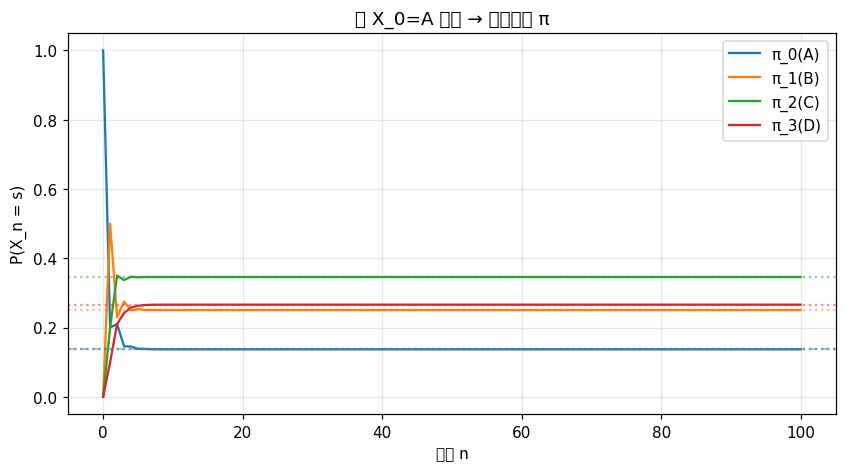

after 100 steps v: [0.1372549  0.25070028 0.34593838 0.26610644]
exact stationary π: [0.1372549  0.25070028 0.34593838 0.26610644]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
# 从 δ_0 开始迭代 v_{n+1} = v_n P
v = np.array([1.0, 0, 0, 0])
history = [v.copy()]
for _ in range(100):
    v = v @ P
    history.append(v.copy())
history = np.array(history)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
for s in range(4):
    ax.plot(history[:, s], label=f"π_{s}({['A','B','C','D'][s]})")
ax.axhline(pi[0], ls="--", color="gray", alpha=0.5)
for s in range(4):
    ax.axhline(pi[s], ls=":", color=f"C{s}", alpha=0.5)
ax.set_xlabel("步数 n"); ax.set_ylabel("P(X_n = s)")
ax.set_title("从 X_0=A 出发 → 平稳分布 π")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

print("after 100 steps v:", v)
print("exact stationary π:", pi)


## 6. 可视化: 多次模拟 vs 解析


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


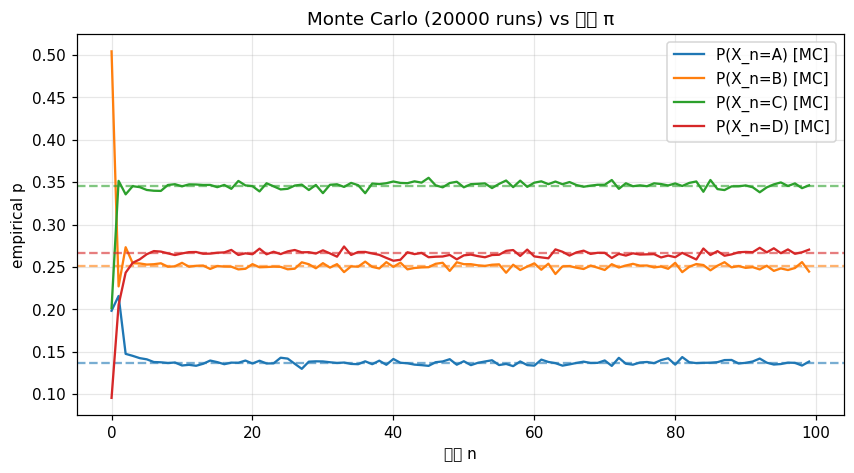

In [5]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)

N_SIM = 20000
N_STEPS = 100
states = np.zeros(N_SIM, dtype=int)  # 都从 0 出发
record = np.zeros((N_STEPS, 4))
for t in range(N_STEPS):
    states_next = np.array([rng.choice(4, p=P[s]) for s in states])
    states = states_next
    for s in range(4):
        record[t, s] = (states == s).mean()

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
for s in range(4):
    ax.plot(record[:, s], lw=1.5, label=f"P(X_n={['A','B','C','D'][s]}) [MC]")
    ax.axhline(pi[s], ls="--", color=f"C{s}", alpha=0.6)
ax.set_xlabel("步数 n"); ax.set_ylabel("empirical p")
ax.set_title(f"Monte Carlo ({N_SIM} runs) vs 解析 π")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 7. 工程案例: Page Rank


In [6]:
import numpy as np

# 6 个模拟网页: A..F
# 链接图 (出度)
links = {
    "A": ["B", "C"],
    "B": ["C"],
    "C": ["A"],
    "D": ["B", "C", "E"],
    "E": ["F"],
    "F": ["E"],
}
N_nodes = len(links); nodes = sorted(links.keys())
idx = {n: i for i, n in enumerate(nodes)}
P = np.zeros((N_nodes, N_nodes))
for src, dsts in links.items():
    for d in dsts:
        P[idx[src], idx[d]] = 1.0 / len(dsts)
# 死胡同节点处理: 跳回任意节点
for i in range(N_nodes):
    if P[i].sum() == 0:
        P[i] = np.ones(N_nodes) / N_nodes
# teleport (damping d=0.85)
d = 0.85
P_G = d * P + (1 - d) / N_nodes * np.ones((N_nodes, N_nodes))

# 迭代直到收敛
v = np.ones(N_nodes) / N_nodes
for _ in range(200):
    v = v @ P_G
print("PageRank (with d=0.85):")
for n, score in sorted(zip(nodes, v), key=lambda x: -x[1]):
    print(f"  {n}: {score:.4f}")


PageRank (with d=0.85):
  C: 0.2382
  A: 0.2275
  E: 0.1922
  F: 0.1884
  B: 0.1288
  D: 0.0250


## 8. pitfalls
- P 不是 irreducible/aperiodic 时收敛方向可能取决于初值 (多解)
- time reversibility 要求 detailed balance; MCMC 候选链要求这条以保后验
- mixing time 不取决于初值, 取决 spectral gap (假一堆石头所有类似 ameliorated)
- Mixing on real-world graph 通常远比线性链慢 (small-world)
- PageRank decomposition: 必须引入 teleport 避免黑洞节点抽走所有概率

## 9. 课后 -> exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Stat 110 | §12.1-12.5 |
| Bertsekas | §7.1-7.4 |
| Murphy | §19.1 (MCMC) |

下一章 ch10: 泊松过程与排队.
